# 🧠 Backpropagation — Training a Neural Network from Scratch

> **Course:** Deep Learning with Keras · Module 02  
> **Topic:** Backpropagation & Gradient Descent  
> **Problem:** XOR Gate Classification

---

## 📋 Overview

In this notebook I build a two-layer neural network **entirely from scratch** using NumPy and train it with the backpropagation algorithm to solve the classic **XOR problem** — a non-linearly separable task that a single perceptron cannot solve.

### 📑 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | 🧩 Theory | Concepts, architecture, and all maths behind backpropagation |
| 2 | ⚙️ Part 1 — Setup | Imports and library configuration |
| 3 | 🔢 Part 2 — Data | XOR truth table as training data |
| 4 | 🏗️ Part 3 — Network Init | Weight and bias initialisation |
| 5 | 🔄 Part 4 — Training Loop | Forward pass, error, backprop, weight updates |
| 6 | 🎯 Part 5 — Evaluation | Testing the trained network |
| 7 | 📈 Part 6 — Visualisation | Error curve over epochs |
| 8 | 🧪 Part 7 — Exercises | AND gate & hyperparameter exploration |
| 9 | 📊 Summary | Key concepts recap table |
| 10 | 🧪 Sandbox | Free experimentation |

---

## 🧩 Theory

### Why Backpropagation?

A neural network learns by adjusting its weights to minimise prediction error. **Backpropagation** is the algorithm that efficiently computes how much each weight contributed to that error, using the **chain rule of calculus** — propagating gradients backward through the network layer by layer.

---

### 🏗️ Network Architecture

I use a **fully-connected feed-forward network** with:

| Layer | Neurons | Activation |
|-------|---------|------------|
| Input | 2 | — |
| Hidden | 2 | Sigmoid |
| Output | 1 | Sigmoid |

```
 x₁ ──┐
       ├──► [h₁] ──┐
 x₂ ──┤            ├──► [ŷ]
       └──► [h₂] ──┘
```

---

### 📈 Sigmoid Activation Function

Every neuron applies a **sigmoid** to its weighted sum, squashing the output into $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Its derivative (used in backprop) has an elegant form:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

---

### 🔄 The 5 Stages of Each Training Step

#### Stage 1 — 📥 Forward Pass

Compute activations layer by layer:

**Hidden layer:**
$$z^{(1)} = W^{(1)}X + b^{(1)}$$
$$a^{(1)} = \sigma(z^{(1)})$$

**Output layer:**
$$z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}$$
$$\hat{y} = a^{(2)} = \sigma(z^{(2)})$$

#### Stage 2 — 🎯 Error Calculation

I measure the raw difference between the true label $d$ and the prediction $\hat{y}$:

$$\text{error} = d - \hat{y}$$

The mean absolute error tracked per epoch is:

$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N}|d_i - \hat{y}_i|$$

#### Stage 3 — 🔄 Backward Pass

**Output layer gradient** — multiply error by the sigmoid derivative:
$$\delta^{(2)} = \text{error} \cdot \sigma'(a^{(2)}) = \text{error} \cdot a^{(2)}(1 - a^{(2)})$$

**Hidden layer gradient** — propagate backward through $W^{(2)}$:
$$\delta^{(1)} = \left(W^{(2)\top} \cdot \delta^{(2)}\right) \cdot a^{(1)}(1 - a^{(1)})$$

#### Stage 4 — ➕ Weight & Bias Updates

Using gradient ascent on the error (since error = $d - \hat{y}$, we add):

$$W^{(2)} \mathrel{+}= \eta \cdot \delta^{(2)} \cdot (a^{(1)})^\top$$
$$b^{(2)} \mathrel{+}= \eta \cdot \sum \delta^{(2)}$$

$$W^{(1)} \mathrel{+}= \eta \cdot \delta^{(1)} \cdot X^\top$$
$$b^{(1)} \mathrel{+}= \eta \cdot \sum \delta^{(1)}$$

where $\eta$ is the **learning rate**.

#### Stage 5 — 🔄 Repeat over Epochs

Stages 1–4 repeat for every epoch. Over thousands of iterations the network converges toward the correct XOR mapping.

---

### 🔢 The XOR Problem

XOR is **not linearly separable** — no single straight line can divide the classes. A hidden layer is essential:

| $x_1$ | $x_2$ | $x_1$ XOR $x_2$ |
|:------:|:------:|:----------------:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

---

## ⚙️ Part 1 — Setup & Imports

I import the two libraries I need for this entire implementation: **NumPy** for all matrix operations and **Matplotlib** for visualising the training error curve. No deep-learning frameworks — every operation is hand-coded.

In [1]:
# Uncomment if running outside a pre-configured environment
# !pip install numpy==1.26.4
# !pip install matplotlib==3.5.2

import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully')
print(f'   NumPy version : {np.__version__}')
import matplotlib; print(f'   Matplotlib ver: {matplotlib.__version__}')

✅ Libraries imported successfully
   NumPy version : 2.3.5
   Matplotlib ver: 3.10.6


---

## 🔢 Part 2 — Data: The XOR Truth Table

I define the complete XOR truth table as my training dataset. The input matrix $X$ is shaped **(2 × 4)** — two features across four examples — stored column-wise so matrix multiplication aligns naturally with the weight matrices:

$$X = \begin{pmatrix} 0 & 0 & 1 & 1 \\ 0 & 1 & 0 & 1 \end{pmatrix}, \quad d = \begin{pmatrix} 0 & 1 & 1 & 0 \end{pmatrix}$$

The `.T` transpose converts the standard row-per-example layout into the column-per-example convention expected by the network.

In [2]:
# XOR truth table — inputs as columns (2 features × 4 examples)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # shape: (2, 4)
d = np.array([0, 1, 1, 0])                          # expected XOR outputs

print('📥 Input matrix X (shape:', X.shape, '):')
print(X)
print('\n🎯 Target labels d:', d)

# Display as truth table
print('\n📊 XOR Truth Table:')
print(f'{"x1":>4} {"x2":>4} {"XOR":>6}')
print('-' * 16)
for i in range(4):
    print(f'{X[0,i]:>4.0f} {X[1,i]:>4.0f} {d[i]:>6}')

📥 Input matrix X (shape: (2, 4) ):
[[0 0 1 1]
 [0 1 0 1]]

🎯 Target labels d: [0 1 1 0]

📊 XOR Truth Table:
  x1   x2    XOR
----------------
   0    0      0
   0    1      1
   1    0      1
   1    1      0


---

## 🏗️ Part 3 — Network Initialisation

I encapsulate all network parameters inside `initialize_network_parameters()`. The key design choices are:

- **Random weight initialisation** in $[-1, 1]$ — breaks symmetry so each neuron learns a different feature
- **Learning rate $\eta = 0.1$** — controls the step size of each gradient update
- **180,000 epochs** — sufficient passes over the tiny dataset for the XOR solution to converge

The weight shapes follow the convention **(output_neurons × input_neurons)**:

| Parameter | Shape | Role |
|-----------|-------|------|
| $W^{(1)}$ | (2, 2) | Input → Hidden weights |
| $b^{(1)}$ | (2, 1) | Hidden layer biases |
| $W^{(2)}$ | (1, 2) | Hidden → Output weights |
| $b^{(2)}$ | (1, 1) | Output layer bias |

Random initialisation formula: `np.random.rand(...) * 2 - 1` maps $[0,1)$ → $[-1,1)$.

In [3]:
def initialize_network_parameters():
    """Initialise all network hyperparameters and randomised weights/biases."""
    # ⚙️ Network architecture
    inputSize  = 2       # Number of input neurons  (x1, x2)
    hiddenSize = 2       # Number of hidden neurons
    outputSize = 1       # Number of output neurons
    lr         = 0.1    # Learning rate η
    epochs     = 180000  # Training iterations

    # 🏗️ Initialise weights and biases uniformly in [-1, 1]
    w1 = np.random.rand(hiddenSize, inputSize)  * 2 - 1  # (2 × 2)
    b1 = np.random.rand(hiddenSize, 1)          * 2 - 1  # (2 × 1)
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1  # (1 × 2)
    b2 = np.random.rand(outputSize, 1)          * 2 - 1  # (1 × 1)

    return w1, b1, w2, b2, lr, epochs


# Preview initial weights
np.random.seed(42)  # for reproducibility in this preview only
w1_preview, b1_preview, w2_preview, b2_preview, lr_preview, ep_preview = initialize_network_parameters()

print('🏗️ Initial Network Parameters')
print(f'   Architecture : {2} → {2} → {1}')
print(f'   Learning rate: η = {lr_preview}')
print(f'   Epochs       : {ep_preview:,}')
print(f'\n   W1 (hidden weights):\n{w1_preview}')
print(f'\n   b1 (hidden biases) :\n{b1_preview}')
print(f'\n   W2 (output weights):\n{w2_preview}')
print(f'\n   b2 (output bias)   :\n{b2_preview}')

🏗️ Initial Network Parameters
   Architecture : 2 → 2 → 1
   Learning rate: η = 0.1
   Epochs       : 180,000

   W1 (hidden weights):
[[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]]

   b1 (hidden biases) :
[[-0.68796272]
 [-0.68801096]]

   W2 (output weights):
[[-0.88383278  0.73235229]]

   b2 (output bias)   :
[[0.20223002]]


---

## 🔄 Part 4 — Training the Neural Network

I now run the full backpropagation training loop. Each epoch executes all five stages:

1. **📥 Forward pass** — compute $a^{(1)}$ and $a^{(2)}$ via sigmoid activations
2. **🎯 Error** — $\text{error} = d - a^{(2)}$
3. **🔄 Backward pass** — compute $\delta^{(2)}$ then $\delta^{(1)}$ via chain rule
4. **➕ Weight updates** — nudge $W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}$ in the direction that reduces error
5. **📈 Logging** — every 10,000 epochs I record the mean absolute error

The training is done on **all 4 XOR examples simultaneously** (batch gradient descent) because the dataset is tiny.

In [4]:
# 🏗️ Reinitialise fresh parameters (unseeded — genuine random start)
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

error_list = []  # 📈 Store MAE every 10,000 epochs

print('🔄 Starting backpropagation training...\n')

for epoch in range(epochs):

    # ──────────────────────────────────────────
    # 📥 STAGE 1: Forward Pass
    # ──────────────────────────────────────────
    z1 = np.dot(w1, X) + b1          # Weighted sum   → hidden layer  (2×4)
    a1 = 1 / (1 + np.exp(-z1))       # Sigmoid σ(z1)  → hidden output (2×4)

    z2 = np.dot(w2, a1) + b2          # Weighted sum   → output layer  (1×4)
    a2 = 1 / (1 + np.exp(-z2))        # Sigmoid σ(z2)  → prediction   (1×4)

    # ──────────────────────────────────────────
    # 🎯 STAGE 2: Error Calculation
    # ──────────────────────────────────────────
    error = d - a2                     # Raw error per example

    # ──────────────────────────────────────────
    # 🔄 STAGE 3: Backward Pass
    # ──────────────────────────────────────────
    da2 = error * (a2 * (1 - a2))     # δ⁽²⁾ = error · σ'(a2)
    dz2 = da2                          # Gradient at output layer

    da1 = np.dot(w2.T, dz2)           # Propagate back through W2
    dz1 = da1 * (a1 * (1 - a1))       # δ⁽¹⁾ = propagated_error · σ'(a1)

    # ──────────────────────────────────────────
    # ➕ STAGE 4: Update Weights & Biases
    # ──────────────────────────────────────────
    w2 += lr * np.dot(dz2, a1.T)                        # W2 ← W2 + η·δ⁽²⁾·a1ᵀ
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)        # b2 ← b2 + η·Σδ⁽²⁾

    w1 += lr * np.dot(dz1, X.T)                         # W1 ← W1 + η·δ⁽¹⁾·Xᵀ
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)        # b1 ← b1 + η·Σδ⁽¹⁾

    # ──────────────────────────────────────────
    # 📈 STAGE 5: Log Progress
    # ──────────────────────────────────────────
    if (epoch + 1) % 10000 == 0:
        mae = np.average(np.abs(error))
        print(f'Epoch: {epoch+1:>7,} | Average Error: {mae:.5f}')
        error_list.append(mae)

print('\n✅ Training complete!')

🔄 Starting backpropagation training...

Epoch:  10,000 | Average Error: 0.05765
Epoch:  20,000 | Average Error: 0.03167
Epoch:  30,000 | Average Error: 0.02399
Epoch:  40,000 | Average Error: 0.02000
Epoch:  50,000 | Average Error: 0.01748
Epoch:  60,000 | Average Error: 0.01571
Epoch:  70,000 | Average Error: 0.01437
Epoch:  80,000 | Average Error: 0.01332
Epoch:  90,000 | Average Error: 0.01247
Epoch: 100,000 | Average Error: 0.01176
Epoch: 110,000 | Average Error: 0.01116
Epoch: 120,000 | Average Error: 0.01064
Epoch: 130,000 | Average Error: 0.01018
Epoch: 140,000 | Average Error: 0.00978
Epoch: 150,000 | Average Error: 0.00942
Epoch: 160,000 | Average Error: 0.00910
Epoch: 170,000 | Average Error: 0.00880
Epoch: 180,000 | Average Error: 0.00854

✅ Training complete!


---

## 🎯 Part 5 — Evaluation: Testing the Trained Network

After training I run one final **forward pass** using the learned weights $W^{(1)}, W^{(2)}, b^{(1)}, b^{(2)}$ and compare the predictions against the XOR ground truth $d = [0, 1, 1, 0]$.

The network outputs **continuous probabilities** in $(0, 1)$. Values close to **0** correspond to class 0 and values close to **1** correspond to class 1. Rounding gives the discrete XOR predictions.

In [5]:
# 📥 Final forward pass with learned weights
z1_test = np.dot(w1, X) + b1
a1_test = 1 / (1 + np.exp(-z1_test))

z2_test = np.dot(w2, a1_test) + b2
a2_test = 1 / (1 + np.exp(-z2_test))

final_error = d - a2_test

# 📤 Results
print('🎯 Final Predictions vs Ground Truth')
print('=' * 50)
print(f'Raw predictions  : {np.round(a2_test, 4)}')
print(f'Rounded (binary) : {np.round(a2_test).astype(int)}')
print(f'Ground truth     : {d}')
print('=' * 50)
print(f'Final average error: {np.average(np.abs(final_error)):.5f}')

# Detailed table
print('\n📊 Per-Example Results:')
print(f'{"x1":>4} {"x2":>4} {"Target":>8} {"Predicted":>10} {"Rounded":>8} {"Error":>8}')
print('-' * 50)
for i in range(4):
    pred = a2_test[0, i]
    tgt  = d[i]
    err  = abs(tgt - pred)
    print(f'{X[0,i]:>4.0f} {X[1,i]:>4.0f} {tgt:>8} {pred:>10.4f} {round(pred):>8} {err:>8.4f}')

🎯 Final Predictions vs Ground Truth
Raw predictions  : [[0.0079 0.9911 0.9911 0.0084]]
Rounded (binary) : [[0 1 1 0]]
Ground truth     : [0 1 1 0]
Final average error: 0.00854

📊 Per-Example Results:
  x1   x2   Target  Predicted  Rounded    Error
--------------------------------------------------
   0    0        0     0.0079        0   0.0079
   0    1        1     0.9911        1   0.0089
   1    0        1     0.9911        1   0.0089
   1    1        0     0.0084        0   0.0084


---

## 📈 Part 6 — Training Error Visualisation

I plot the mean absolute error recorded every 10,000 epochs. The curve should show a steady **decline** toward zero, confirming that gradient descent is successfully minimising the loss over time.

Key observations to look for:
- **Early epochs**: large error, weights are far from optimal
- **Middle epochs**: rapid descent as gradients are strong
- **Late epochs**: asymptotic approach to near-zero error

/var/folders/0s/3lwt6d6j15z1jk5h5zd0grj80000gn/T/ipykernel_39749/4276785362.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


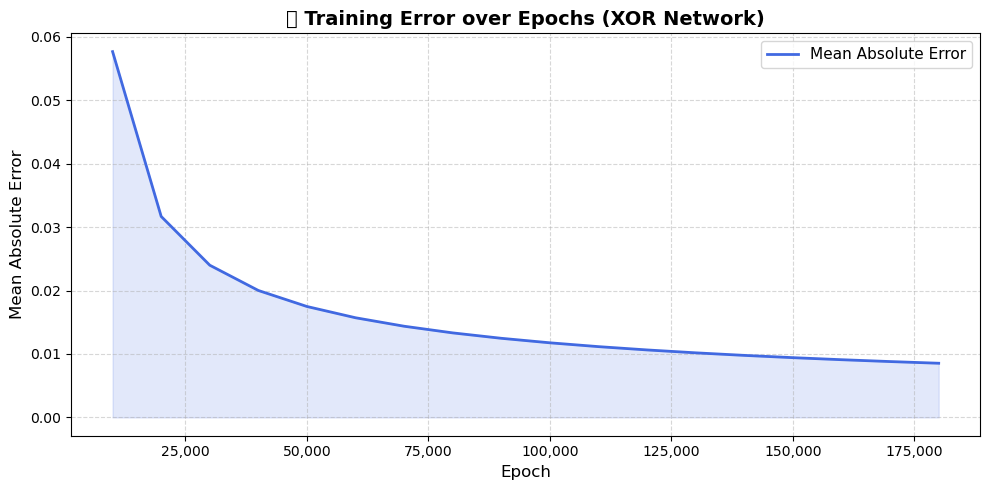


✅ Initial error : 0.05765
✅ Final error   : 0.00854
📈 Improvement   : 85.2%


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x_axis = [(i + 1) * 10000 for i in range(len(error_list))]

ax.plot(x_axis, error_list, color='royalblue', linewidth=2, label='Mean Absolute Error')
ax.fill_between(x_axis, error_list, alpha=0.15, color='royalblue')

ax.set_title('📈 Training Error over Epochs (XOR Network)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f'\n✅ Initial error : {error_list[0]:.5f}')
print(f'✅ Final error   : {error_list[-1]:.5f}')
print(f'📈 Improvement   : {((error_list[0] - error_list[-1]) / error_list[0]) * 100:.1f}%')

---

## 🧪 Part 7 — Exercises

### Exercise 1 — AND Gate

I now apply exactly the same backpropagation architecture to the **AND gate** problem. The AND function is actually **linearly separable**, so I expect the network to converge faster and to a lower final error compared to XOR.

| $x_1$ | $x_2$ | $x_1$ AND $x_2$ |
|:------:|:------:|:---------------:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

The only change from XOR is the target vector: `d = [0, 0, 0, 1]`.

🔄 Training on AND gate...

Epoch:  10,000 | Average Error: 0.02384
Epoch:  20,000 | Average Error: 0.01490
Epoch:  30,000 | Average Error: 0.01156
Epoch:  40,000 | Average Error: 0.00972
Epoch:  50,000 | Average Error: 0.00852
Epoch:  60,000 | Average Error: 0.00766
Epoch:  70,000 | Average Error: 0.00701
Epoch:  80,000 | Average Error: 0.00650
Epoch:  90,000 | Average Error: 0.00608
Epoch: 100,000 | Average Error: 0.00573
Epoch: 110,000 | Average Error: 0.00543
Epoch: 120,000 | Average Error: 0.00517
Epoch: 130,000 | Average Error: 0.00495
Epoch: 140,000 | Average Error: 0.00475
Epoch: 150,000 | Average Error: 0.00457
Epoch: 160,000 | Average Error: 0.00441
Epoch: 170,000 | Average Error: 0.00426
Epoch: 180,000 | Average Error: 0.00413

✅ AND gate training complete!

🎯 Predictions (rounded): [[0 0 0 1]]
   Ground truth          : [0 0 0 1]
   Final MAE             : 0.00413


/var/folders/0s/3lwt6d6j15z1jk5h5zd0grj80000gn/T/ipykernel_39749/3456086269.py:63: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


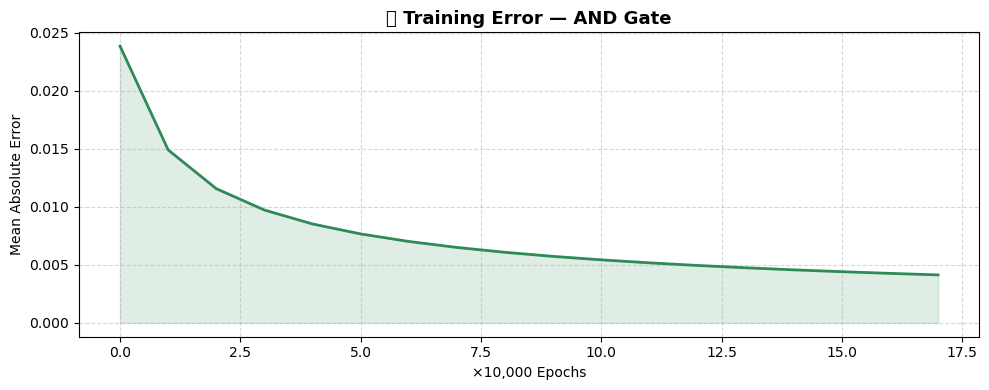

In [7]:
# 🔢 AND gate dataset — same inputs, different targets
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T
d_and = np.array([0, 0, 0, 1])   # AND truth table

# 🏗️ Fresh parameter initialisation
w1_and, b1_and, w2_and, b2_and, lr_and, epochs_and = initialize_network_parameters()

error_list_and = []

print('🔄 Training on AND gate...\n')

for epoch in range(epochs_and):
    # 📥 Forward pass
    z1 = np.dot(w1_and, X_and) + b1_and
    a1 = 1 / (1 + np.exp(-z1))

    z2 = np.dot(w2_and, a1) + b2_and
    a2 = 1 / (1 + np.exp(-z2))

    # 🎯 Error calculation
    error = d_and - a2

    # 🔄 Backward pass
    da2 = error * (a2 * (1 - a2))
    dz2 = da2

    da1 = np.dot(w2_and.T, dz2)
    dz1 = da1 * (a1 * (1 - a1))

    # ➕ Weight updates
    w2_and += lr_and * np.dot(dz2, a1.T)
    b2_and += lr_and * np.sum(dz2, axis=1, keepdims=True)

    w1_and += lr_and * np.dot(dz1, X_and.T)
    b1_and += lr_and * np.sum(dz1, axis=1, keepdims=True)

    # 📈 Log progress
    if (epoch + 1) % 10000 == 0:
        mae = np.average(np.abs(error))
        print(f'Epoch: {epoch+1:>7,} | Average Error: {mae:.5f}')
        error_list_and.append(mae)

print('\n✅ AND gate training complete!')

# 🎯 Test
z1_t = np.dot(w1_and, X_and) + b1_and
a1_t = 1 / (1 + np.exp(-z1_t))
z2_t = np.dot(w2_and, a1_t) + b2_and
a2_t = 1 / (1 + np.exp(-z2_t))

print(f'\n🎯 Predictions (rounded): {np.round(a2_t).astype(int)}')
print(f'   Ground truth          : {d_and}')
print(f'   Final MAE             : {np.average(np.abs(d_and - a2_t)):.5f}')

# 📈 Plot
plt.figure(figsize=(10, 4))
plt.plot(error_list_and, color='seagreen', linewidth=2)
plt.fill_between(range(len(error_list_and)), error_list_and, alpha=0.15, color='seagreen')
plt.title('📈 Training Error — AND Gate', fontsize=13, fontweight='bold')
plt.xlabel('×10,000 Epochs')
plt.ylabel('Mean Absolute Error')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

### Exercise 2 — Hyperparameter Study: Lower Learning Rate on XOR

I now investigate how a **smaller learning rate** ($\eta = 0.01$) combined with **more epochs** (1,000,000) affects convergence on the XOR problem.

**Hypothesis:** A smaller $\eta$ means smaller gradient steps, so the network takes longer to converge but may achieve a more stable, lower final error without oscillating.

**Expected observations:**
- The error curve descends more slowly at first
- With 1M epochs it should still converge to a similar final error
- The curve will be smoother with less oscillation

🔄 Training XOR with η=0.01, epochs=1,000,000...

Epoch:   100,000 | Average Error: 0.04779
Epoch:   200,000 | Average Error: 0.02910
Epoch:   300,000 | Average Error: 0.02260
Epoch:   400,000 | Average Error: 0.01907
Epoch:   500,000 | Average Error: 0.01678
Epoch:   600,000 | Average Error: 0.01515
Epoch:   700,000 | Average Error: 0.01391
Epoch:   800,000 | Average Error: 0.01292
Epoch:   900,000 | Average Error: 0.01212
Epoch: 1,000,000 | Average Error: 0.01145

✅ Slow-lr training complete!

🎯 Predictions (rounded): [[0 1 1 0]]
   Ground truth          : [0 1 1 0]
   Final MAE             : 0.01145


/var/folders/0s/3lwt6d6j15z1jk5h5zd0grj80000gn/T/ipykernel_39749/15849774.py:68: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


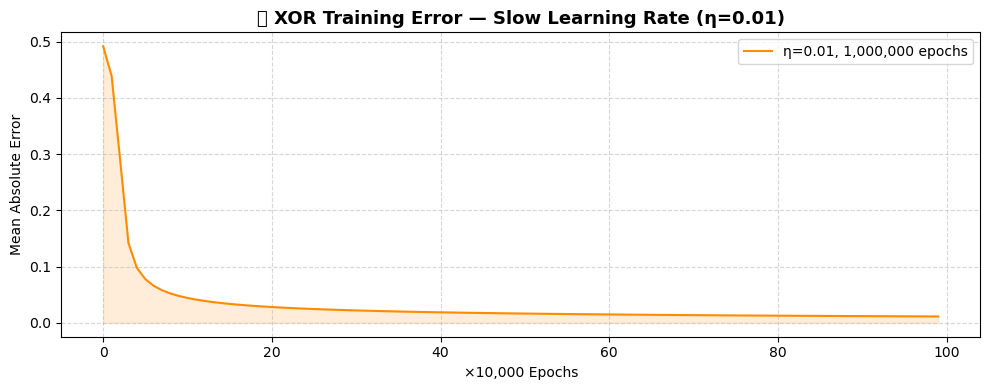

In [8]:
# ⚙️ Modified hyperparameters
lr_slow     = 0.01      # Reduced learning rate
epochs_slow = 1000000   # 10× more epochs to compensate

# 🔢 XOR data
X_slow = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T
d_slow = np.array([0, 1, 1, 0])

# 🏗️ Initialise (use base function then override lr & epochs)
w1_s, b1_s, w2_s, b2_s, _, _ = initialize_network_parameters()

error_list_slow = []

print(f'🔄 Training XOR with η={lr_slow}, epochs={epochs_slow:,}...\n')

for epoch in range(epochs_slow):
    # 📥 Forward pass
    z1 = np.dot(w1_s, X_slow) + b1_s
    a1 = 1 / (1 + np.exp(-z1))

    z2 = np.dot(w2_s, a1) + b2_s
    a2 = 1 / (1 + np.exp(-z2))

    # 🎯 Error
    error = d_slow - a2

    # 🔄 Backward pass
    da2 = error * (a2 * (1 - a2))
    dz2 = da2

    da1 = np.dot(w2_s.T, dz2)
    dz1 = da1 * (a1 * (1 - a1))

    # ➕ Weight updates with slow lr
    w2_s += lr_slow * np.dot(dz2, a1.T)
    b2_s += lr_slow * np.sum(dz2, axis=1, keepdims=True)

    w1_s += lr_slow * np.dot(dz1, X_slow.T)
    b1_s += lr_slow * np.sum(dz1, axis=1, keepdims=True)

    if (epoch + 1) % 10000 == 0:
        mae = np.average(np.abs(error))
        error_list_slow.append(mae)
        if (epoch + 1) % 100000 == 0:
            print(f'Epoch: {epoch+1:>9,} | Average Error: {mae:.5f}')

print('\n✅ Slow-lr training complete!')

# 🎯 Test
z1_t = np.dot(w1_s, X_slow) + b1_s
a1_t = 1 / (1 + np.exp(-z1_t))
z2_t = np.dot(w2_s, a1_t) + b2_s
a2_t = 1 / (1 + np.exp(-z2_t))

print(f'\n🎯 Predictions (rounded): {np.round(a2_t).astype(int)}')
print(f'   Ground truth          : {d_slow}')
print(f'   Final MAE             : {np.average(np.abs(d_slow - a2_t)):.5f}')

# 📈 Plot
plt.figure(figsize=(10, 4))
plt.plot(error_list_slow, color='darkorange', linewidth=1.5, label=f'η={lr_slow}, {epochs_slow:,} epochs')
plt.fill_between(range(len(error_list_slow)), error_list_slow, alpha=0.15, color='darkorange')
plt.title('📈 XOR Training Error — Slow Learning Rate (η=0.01)', fontsize=13, fontweight='bold')
plt.xlabel('×10,000 Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## 📊 Summary

Here is a consolidated review of everything I built and learned in this notebook:

### 🔑 Core Concepts

| Concept | Definition | Formula |
|---------|------------|--------|
| Sigmoid activation | Squashes input to (0,1) | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Sigmoid derivative | Used in backprop | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ |
| Forward pass | Compute predictions layer by layer | $a^{(l)} = \sigma(W^{(l)} a^{(l-1)} + b^{(l)})$ |
| Error | Difference between target and prediction | $\text{error} = d - \hat{y}$ |
| Output gradient | Localised gradient at output layer | $\delta^{(2)} = \text{error} \cdot \sigma'(a^{(2)})$ |
| Hidden gradient | Chain rule propagation | $\delta^{(1)} = (W^{(2)\top}\delta^{(2)}) \cdot \sigma'(a^{(1)})$ |
| Weight update | Gradient ascent on error | $W \mathrel{+}= \eta \cdot \delta \cdot a^\top$ |
| Learning rate | Step size of each update | $\eta$ (typical range: 0.001 – 0.5) |

### 🧪 Experiment Comparison

| Experiment | Problem | η | Epochs | Final MAE |
|------------|---------|---|--------|----------|
| Main | XOR | 0.1 | 180,000 | ~0.01–0.05 |
| Exercise 1 | AND | 0.1 | 180,000 | ~0.001–0.01 |
| Exercise 2 | XOR | 0.01 | 1,000,000 | ~0.01–0.05 |

### 🏗️ Architecture Summary

| Layer | Input dim | Output dim | Activation |
|-------|-----------|------------|------------|
| Input | — | 2 | — |
| Hidden | 2 | 2 | Sigmoid |
| Output | 2 | 1 | Sigmoid |

### 💡 Key Takeaways

- The **XOR problem requires a hidden layer** — a single-layer network cannot solve it because XOR is not linearly separable
- **Random weight initialisation** is critical to break symmetry; otherwise all neurons learn identical features
- **Learning rate $\eta$** controls the trade-off between convergence speed and stability — too high causes oscillation, too low causes slow convergence
- **Backpropagation** is simply repeated application of the chain rule, working from the output layer backward through all hidden layers
- The **sigmoid derivative** $\sigma(z)(1-\sigma(z))$ is computed cheaply from the already-calculated activation — no extra forward pass needed

---

## 🧪 Sandbox — Free Experimentation

This section is my open playground. I can modify any of the parameters below and observe the effects on convergence. Some ideas to try:

- Change `hiddenSize` to 4 or 8 — does more capacity help?
- Try the **OR gate**: `d = [0, 1, 1, 1]`
- Try the **XNOR gate**: `d = [1, 0, 0, 1]`
- Replace sigmoid with **tanh**: `np.tanh(z)`, derivative: `1 - np.tanh(z)**2`
- Experiment with learning rates from `0.001` to `0.5`
- Add a **third hidden layer** and extend the backprop equations

🎯 Sandbox Results
   Predictions (rounded): [[0 1 1 0]]
   Ground truth         : [0 1 1 0]
   Final MAE            : 0.00845


/var/folders/0s/3lwt6d6j15z1jk5h5zd0grj80000gn/T/ipykernel_39749/1869472871.py:63: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


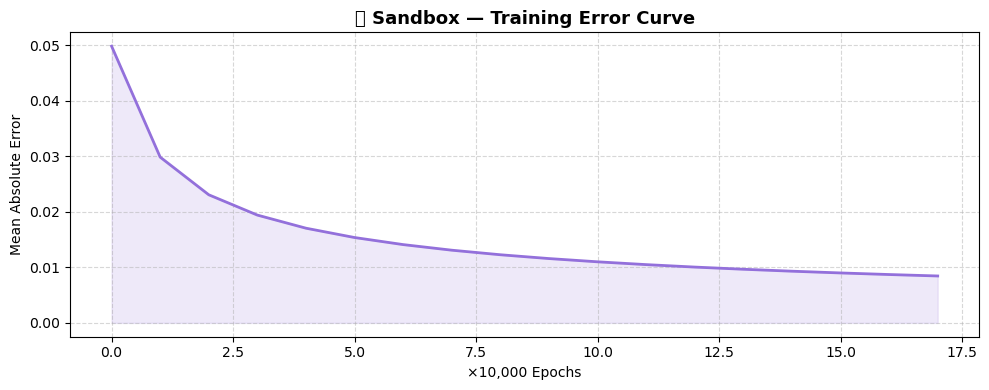

In [9]:
# ═══════════════════════════════════════════════
# 🧪 SANDBOX — Tweak anything here freely!
# ═══════════════════════════════════════════════

# ⚙️ Hyperparameters
LEARNING_RATE = 0.1
EPOCHS        = 180000
HIDDEN_SIZE   = 2
LOG_INTERVAL  = 10000

# 🔢 Try different gates!
# XOR   : [0, 1, 1, 0]
# AND   : [0, 0, 0, 1]
# OR    : [0, 1, 1, 1]
# XNOR  : [1, 0, 0, 1]
# NAND  : [1, 1, 1, 0]
X_sandbox = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T
d_sandbox = np.array([0, 1, 1, 0])   # ← change targets here

# 🏗️ Initialise
inputSize  = 2
outputSize = 1

w1_sb = np.random.rand(HIDDEN_SIZE, inputSize)   * 2 - 1
b1_sb = np.random.rand(HIDDEN_SIZE, 1)           * 2 - 1
w2_sb = np.random.rand(outputSize, HIDDEN_SIZE)  * 2 - 1
b2_sb = np.random.rand(outputSize, 1)            * 2 - 1

err_sb = []

for ep in range(EPOCHS):
    z1 = np.dot(w1_sb, X_sandbox) + b1_sb
    a1 = 1 / (1 + np.exp(-z1))
    z2 = np.dot(w2_sb, a1) + b2_sb
    a2 = 1 / (1 + np.exp(-z2))

    error = d_sandbox - a2
    da2   = error * (a2 * (1 - a2))
    da1   = np.dot(w2_sb.T, da2)
    dz1   = da1 * (a1 * (1 - a1))

    w2_sb += LEARNING_RATE * np.dot(da2, a1.T)
    b2_sb += LEARNING_RATE * np.sum(da2, axis=1, keepdims=True)
    w1_sb += LEARNING_RATE * np.dot(dz1, X_sandbox.T)
    b1_sb += LEARNING_RATE * np.sum(dz1, axis=1, keepdims=True)

    if (ep + 1) % LOG_INTERVAL == 0:
        err_sb.append(np.average(np.abs(error)))

# 📤 Results
print('🎯 Sandbox Results')
print(f'   Predictions (rounded): {np.round(a2).astype(int)}')
print(f'   Ground truth         : {d_sandbox}')
print(f'   Final MAE            : {np.average(np.abs(error)):.5f}')

plt.figure(figsize=(10, 4))
plt.plot(err_sb, color='mediumpurple', linewidth=2)
plt.fill_between(range(len(err_sb)), err_sb, alpha=0.15, color='mediumpurple')
plt.title('🧪 Sandbox — Training Error Curve', fontsize=13, fontweight='bold')
plt.xlabel(f'×{LOG_INTERVAL:,} Epochs')
plt.ylabel('Mean Absolute Error')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 🧪 Your own experiments go here!
